# PTA Likelihood vs Pulsar Distance

This notebook demonstrates how the PTA log-likelihood varies as a function of
a single pulsar's distance in the presence of a continuous gravitational wave (CW) source.

We generate **N** random pulsars (white noise + spindown timing models) and
**M** CW sources, then sweep the distance of one pulsar while holding everything
else fixed.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt 

In [ ]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")  # silence PINT's DEBUG/INFO chatter

from io import StringIO

import jax
import jax.numpy as jnp
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_1d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 100  # plots up to M CW sources on same graph
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0    # ~8 yr observation span
TOA_ERROR = 1e-8     # 10 ns (reduced to make CW signal prominent)
FREQ = 1400.0        # MHz
SEED = 42


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, DM, and
distance. We build a minimal `.par` string and parse it with PINT.

**Convention:** `CWInjector` reads the `PX` parameter directly as distance in kpc
(not parallax in mas). We set `PX` in the `.par` file accordingly.

In [ ]:
rng = np.random.default_rng(SEED)

par_strings = [
    generate_random_par(
        idx, rng,
        start_mjd=START_MJD,
        include_dm=True,
        extra_params={"EQUAD tel gbt": "0.1"},
    )
    for idx in range(N_PULSARS)
]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


## Generate fake TOAs and convert to JaxPINT

In [ ]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD,
    end_mjd=END_MJD,
    n_toas=N_TOAS,
    toa_error_s=TOA_ERROR,
    freq_mhz=FREQ,
)
# Aliases matching the rest of the notebook
toa_data_list = list(synthetic.toa_data_list)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
base_toa_data_list = list(synthetic.toa_data_list)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_val = float(pulsar_params_list[i].param_value("PX"))
    f0_val = float(pulsar_params_list[i].param_value("F0"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  F0={f0_val:.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")


## Set up CW source and PTA config

We place several CW sources at a random sky location with random nHz GW frequency  and
strain amplitude $h \sim 10^{-12}$.

In [ ]:
all_cw_injectors, positions = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-12.0,
)
all_cw_injectors = list(all_cw_injectors)

for m, inj in enumerate(all_cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

print(f"\nGenerated {M_CW_SOURCES} CW sources total")


## Sweep distance for pulsar 0

We vary the distance (PX parameter) of pulsar 0 over a grid while keeping all
other parameters fixed, and evaluate the PTA log-likelihood at each point.

The CW pulsar-term phase depends on distance as
$\phi_p = \phi_e - 2\pi f_{\rm gw} \frac{d}{c}(1 + \cos\mu)$,
so the likelihood oscillates with distance.

In [ ]:
TARGET_PULSAR = 0
true_distance = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc")

half_window = 0.01  # kpc
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    500,
)

M_values = [1, 2, 5, 10, 20, 50, M_CW_SOURCES]
results = {}  # M -> logL_values

for M in M_values:
    print(f"\n--- M = {M} CW source(s) ---")
    cw_subset = all_cw_injectors[:M]
    gp, cfg = inject_and_build_config(synthetic, cw_subset)

    def _eval(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    results[M] = sweep_1d_logL(_eval, distance_grid)
    print(f"  Sweep complete ({len(distance_grid)} points)")

print("\nAll sweeps done.")


## Plot Likelihood

In [ ]:
# Fit the target pulsar with JaxPINT's WLS fitter to get PX uncertainty
from jaxpint.fitters import WLSFitter
from jaxpint.types import ParameterVector
import matplotlib.pyplot as plt

target_params = pp_tuple[TARGET_PULSAR]
px_idx = target_params.names.index("PX")
new_frozen = list(target_params.frozen_mask)
new_frozen[px_idx] = False
fit_params = ParameterVector(
    values=target_params.values,
    frozen_mask=tuple(new_frozen),
    names=target_params.names,
    units=target_params.units,
    epoch_int_values=target_params.epoch_int_values,
)

fitter = WLSFitter(
    timing_models[TARGET_PULSAR],
    base_toa_data_list[TARGET_PULSAR],
    fit_params,
    noise_models[TARGET_PULSAR],
)
fit_result = fitter.fit_toas()

free_names = [fit_params.names[i] for i in fit_params._free_indices]
px_free_idx = free_names.index("PX")
px_err = float(fit_result.parameter_uncertainties[px_free_idx])

print(f"JaxPINT WLS fitter result for pulsar {TARGET_PULSAR}:")
print(f"  PX = {float(fit_result.params.param_value('PX')):.6f} +/- {px_err:.6f} kpc (1-sigma)")

fig, ax = plt.subplots(figsize=(12, 6))
ax.axvspan(
    true_distance - px_err, true_distance + px_err,
    alpha=0.15, color="gray", label=f"Fitter 1$\\sigma$ = {px_err:.4f} kpc",
)
for M in M_values:
    plot_1d_delta_logL(
        ax, distance_grid, results[M],
        label=f"M = {M} CW source{'s' if M > 1 else ''}",
    )
ax.axvline(
    true_distance, color="black", linestyle="--", linewidth=1.5,
    label=f"True distance = {true_distance:.2f} kpc",
)
ax.set_yscale("symlog", linthresh=1e0)
ax.set_xlabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood vs distance for pulsar {TARGET_PULSAR}\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, varying number of CW sources)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


## Fisher Information Analysis

The Fisher information $F = -\frac{d^2 \log L}{d(\text{PX})^2}$ at the true distance
quantifies how tightly the likelihood constrains the distance. The Cramér-Rao bound
gives the minimum uncertainty: $\sigma_d \geq 1/\sqrt{F}$.

### Fisher information vs number of CW sources


In [ ]:
M_sweep = [1, 2, 5, 10, 20, 50, M_CW_SOURCES]
fisher_vs_M = []
sigma_vs_M = []

for M in M_sweep:
    cw_subset = all_cw_injectors[:M]
    gp, cfg = inject_and_build_config(synthetic, cw_subset)

    @jax.jit
    def _eval_fisher(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_fisher)))(jnp.float64(true_distance)))
    fisher_vs_M.append(F)
    sigma_vs_M.append(1.0 / np.sqrt(abs(F)))

    if M % 10 == 0 or M <= 5:
        print(f"  M={M:3d}: F={F:.4e}, sigma_d={sigma_vs_M[-1]:.4e} kpc")

fisher_vs_M = np.array(fisher_vs_M)
sigma_vs_M = np.array(sigma_vs_M)
print("Done.")


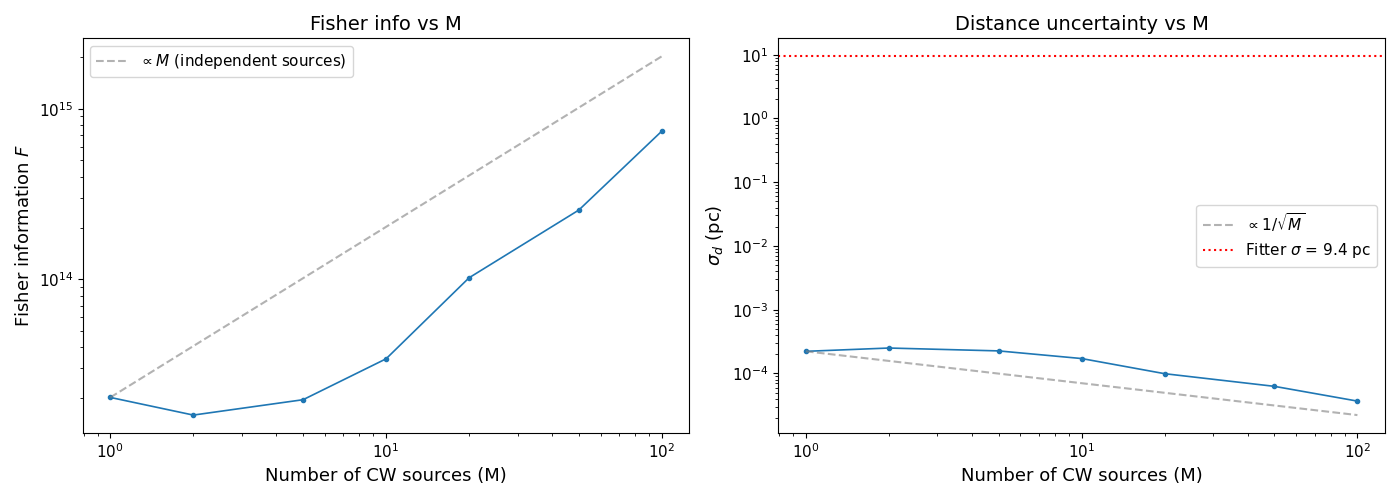

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fisher info vs M
ax1.loglog(M_sweep, fisher_vs_M, "o-", markersize=3, linewidth=1.2)
# Reference: linear scaling from M=1
ax1.loglog(M_sweep, fisher_vs_M[0] * np.array(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto M$ (independent sources)")
ax1.set_xlabel("Number of CW sources (M)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs M", fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

# sigma_d vs M
ax2.loglog(M_sweep, sigma_vs_M * 1e3, "o-", markersize=3, linewidth=1.2)  # convert to pc
ax2.loglog(M_sweep, sigma_vs_M[0] * 1e3 / np.sqrt(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto 1/\\sqrt{M}$")
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("Number of CW sources (M)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)  
ax2.set_title("Distance uncertainty vs M", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

### Fisher information vs GW frequency

Fix M=1 and sweep the CW source frequency. Higher frequency means faster
distance oscillations (shorter wavelength in distance space), which should
increase the local curvature of the likelihood peak.

In [ ]:
# Use CW source 0 as a template, varying only log10_fgw
template_spec = dict(all_cw_injectors[0].param_spec)

log10_fgw_grid = np.linspace(-9, -7, 40)
fisher_vs_freq = []
sigma_vs_freq = []

for log10_f in log10_fgw_grid:
    spec = dict(template_spec)
    spec["log10_fgw"] = float(log10_f)
    inj = CWInjector(positions, prefix="cwfreq_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))

    @jax.jit
    def _eval_freq(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_freq)))(jnp.float64(true_distance)))
    fisher_vs_freq.append(F)
    sigma_vs_freq.append(1.0 / np.sqrt(abs(F)))

fisher_vs_freq = np.array(fisher_vs_freq)
sigma_vs_freq = np.array(sigma_vs_freq)
print("Done.")


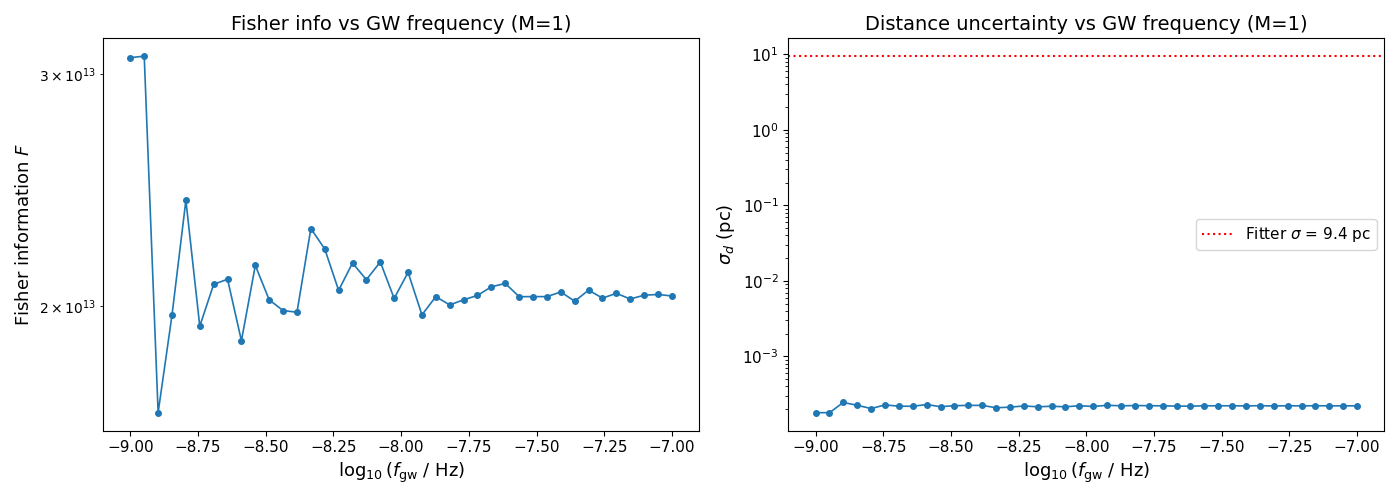

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_fgw_grid, fisher_vs_freq, "o-", markersize=4, linewidth=1.2)
ax1.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs GW frequency (M=1)", fontsize=14)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_fgw_grid, sigma_vs_freq * 1e3, "o-", markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)
ax2.set_title("Distance uncertainty vs GW frequency (M=1)", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

### Fisher information vs CW strain amplitude

Fix M=1 and sweep `log10_h`. Since the CW delay scales as $h / (2\pi f_{\rm gw})$,
the signal-to-noise ratio scales linearly with $h$, so we expect $F \propto h^2$.

In [ ]:
# Use CW source 0 as a template, varying only log10_h
template_spec_h = dict(all_cw_injectors[0].param_spec)

log10_h_grid = np.linspace(-15, -11, 40)
fisher_vs_h = []
sigma_vs_h = []

for log10_h in log10_h_grid:
    spec = dict(template_spec_h)
    spec["log10_h"] = float(log10_h)
    inj = CWInjector(positions, prefix="cwamp_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))

    @jax.jit
    def _eval_amp(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_amp)))(jnp.float64(true_distance)))
    fisher_vs_h.append(F)
    sigma_vs_h.append(1.0 / np.sqrt(abs(F)))

fisher_vs_h = np.array(fisher_vs_h)
sigma_vs_h = np.array(sigma_vs_h)
print("Done.")


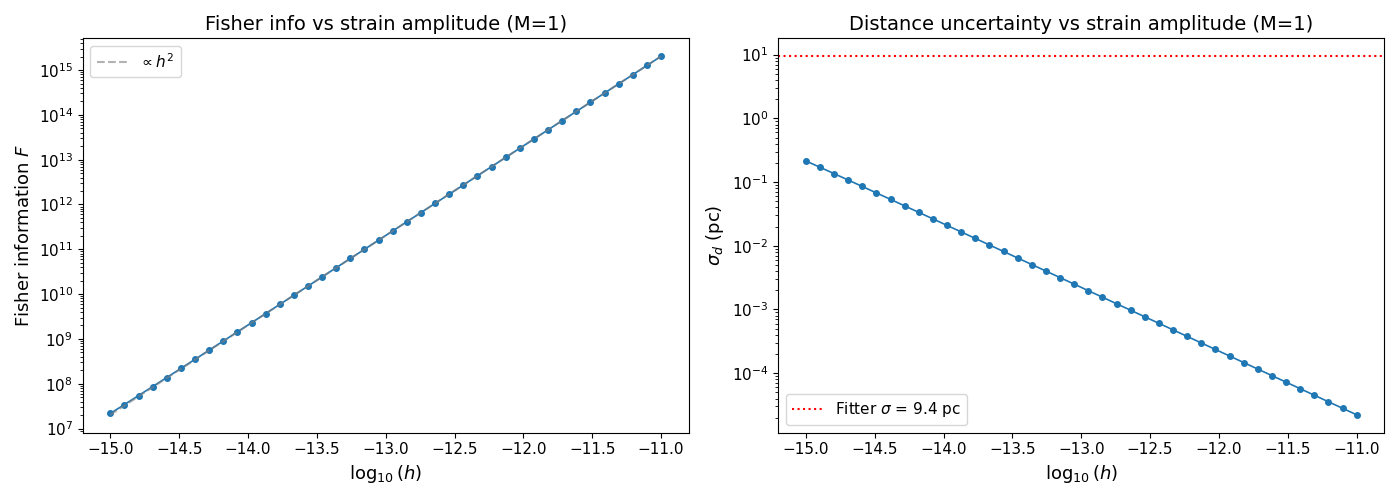

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_h_grid, fisher_vs_h, 'o-', markersize=4, linewidth=1.2)
# Reference: h^2 scaling
h_ref = 10.0 ** log10_h_grid
h0 = 10.0 ** log10_h_grid[len(log10_h_grid)//2]
F0 = fisher_vs_h[len(log10_h_grid)//2]
ax1.semilogy(log10_h_grid, F0 * (h_ref / h0)**2, '--', color='gray',
             alpha=0.6, label='$\\propto h^2$')
ax1.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax1.set_ylabel('Fisher information $F$', fontsize=13)
ax1.set_title('Fisher info vs strain amplitude (M=1)', fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_h_grid, sigma_vs_h * 1e3, 'o-', markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color='red', linestyle=':', linewidth=1.5,
            label=f'Fitter $\\sigma$ = {px_err*1e3:.1f} pc')
ax2.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax2.set_ylabel('$\\sigma_d$ (pc)', fontsize=13)
ax2.set_title('Distance uncertainty vs strain amplitude (M=1)', fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()